# Tienda de Ropa
Modelo de aprendizaje automático

## 1. Importar librerías

In [8]:
# Importar librerías
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import math
import numpy as np

## 2. Descargar el dataset

In [19]:
# 2. Descargar el dataset de Fashion MNIST de Zalanda
datos, metadatos = tfds.load('fashion_mnist', as_supervised=True, with_info=True)

**as_supervised:** indica como se entregan los datos (True, en forma de tupla. False, en forma de diccionario)
**with_info:** Define qué objetos devuelve la función (True, datos + metadatos. Flase, sólo datos)

# 3. Imprimir los metadatos

In [14]:
metadatos

tfds.core.DatasetInfo(
    name='fashion_mnist',
    full_name='fashion_mnist/3.0.1',
    description="""
    Fashion-MNIST is a dataset of Zalando's article images consisting of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes.
    """,
    homepage='https://github.com/zalandoresearch/fashion-mnist',
    data_dir='/Users/danylitzy/tensorflow_datasets/fashion_mnist/3.0.1',
    file_format=tfrecord,
    download_size=29.45 MiB,
    dataset_size=36.42 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_examples=10000, num_shards=1>,
        'train': <SplitInfo num_examples=60000, num_shards=1>,
    },
    citation="""@article{DBLP:jo

## 4. Ordenar cada conjunto de datos en las variables correspondientes

In [16]:
# Obtenemos en variables separadas los datos de entrenamiento(60k) y prubas (10k)
datos_entrenamiento, datos_pruebas = datos['train'], datos['test']

## 5. Asignar los nombres de las categorías (incluidas en el dataset) a una variable y mostrarlas

In [18]:
nombres_clases = metadatos.features['label'].names
nombres_clases

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

## 6. Normalizar los datos

In [20]:
def normalizar(imagenes, etiquetas):
    imagenes = tf.cast(imagenes, tf.float32)
    imagenes /= 255 #Aquí lo pasa de 0-255 a 0-1
    return imagenes, etiquetas

#utilizar función de normalizar
datos_entrenamiento = datos_entrenamiento.map(normalizar)
datos_pruebas = datos_pruebas.map(normalizar)

# guardar datos en caché
datos_entrenamiento = datos_entrenamiento.cache()
datos_pruebas = datos_pruebas.cache()

**map():** Recorre el dataset y ejecuta la función que le pases a cada ejemplo.

## 7. Mostrar imágenes del dataset

2026-03-09 17:16:34.055366: W tensorflow/core/kernels/data/cache_dataset_ops.cc:914] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2026-03-09 17:16:34.055674: W tensorflow/core/kernels/data/cache_dataset_ops.cc:914] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


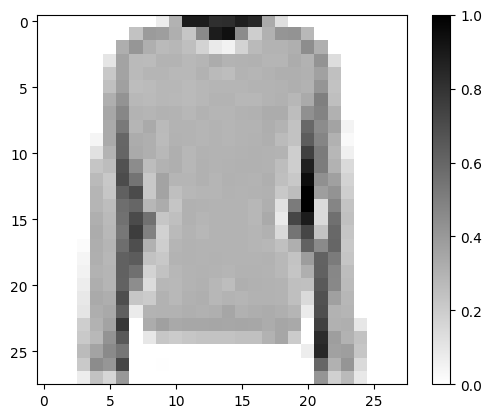

In [23]:
# Mostrar una imagen de los datos de pruebas
for imagen, etiqueta in datos_entrenamiento.take(1):
    break
imagen = imagen.numpy().reshape((28,28)) #Redimensionar los pixeles

#Dibujar
plt.figure()
plt.imshow(imagen, cmap=plt.cm.binary)
plt.colorbar()
plt.grid(False)
plt.show()

2026-03-09 17:19:24.408539: W tensorflow/core/kernels/data/cache_dataset_ops.cc:914] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2026-03-09 17:19:24.408612: W tensorflow/core/kernels/data/cache_dataset_ops.cc:914] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2026-03-09 17:19:24.412047: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence

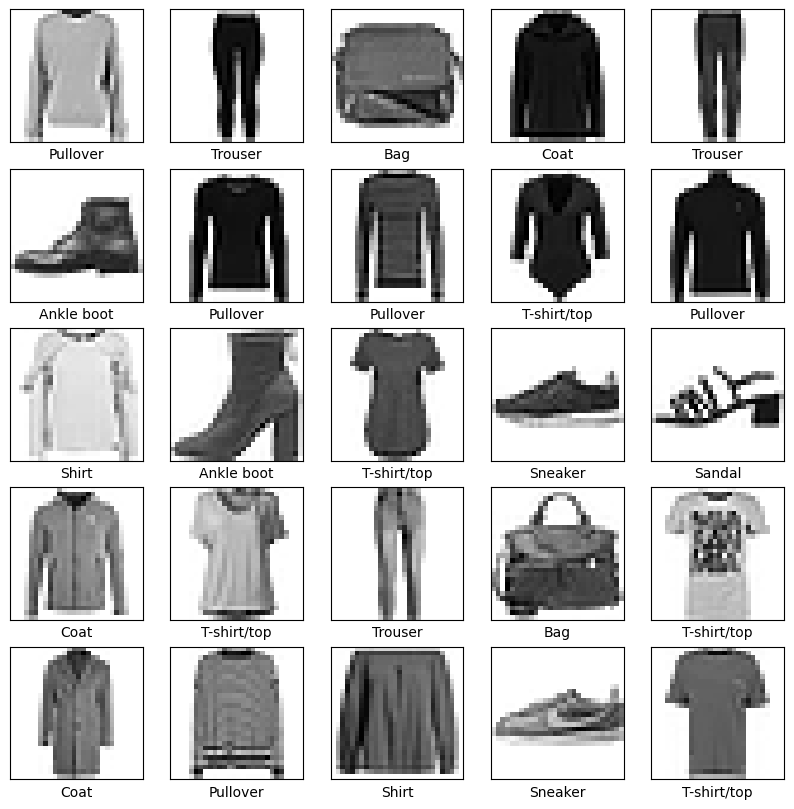

In [26]:
#Mostrar imagen por cada categoría con su etiqueta
plt.figure(figsize=(10,10))
for i, (imagen, etiqueta) in enumerate(datos_entrenamiento.take(25)):
    imagen = imagen.numpy().reshape((28,28))
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(imagen, cmap=plt.cm.binary)
    plt.xlabel(nombres_clases[etiqueta])
plt.show()

## 8. Creación del modelo

* Se utiliza una red de tipo secuencial.
* Se define una capa de entrada de forma manual utilizando la función Flatten(), cuya objetivo es, convertir a una dimensión los datos de entrada. Es decir, la matriz original en 2D de 28x28 se convierte a un vector de 784 neuronas.
* Agregar dos capas ocultas de 50 neuronas cada una y una función de activación ReLU.
* Agregar la capa de salida con 10 neuronas y una función de activación SoftMax, la cuál es muy comúnmente utilizada en redes de clasificación, para que la suma de las neuronas de salidas sólo de cómo resultado 1.

In [27]:
# Crear el modelo
modelo = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28,1)), #1 - blanco y negro
    tf.keras.layers.Dense(50, activation=tf.nn.relu),
    tf.keras.layers.Dense(50, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax) #Para redes de clasificación
])

/opt/anaconda3/envs/tf-env/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## 9. Compilar el modelo
* Se implementa adam como optimizador
* La función de perdida utilizada será SparseCategoricalCrossentropy(), ya que es común utilizarla
en redes de clasificación.

In [28]:
#Compilar el modelo
modelo.compile(
    optimizer='adam', 
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

## 10. Dividir por lotes
Dividir por lotes permite que entrenamientos con gran cantidad de datos se haga de manera más eficiente

In [30]:
TAMANO_LOTE = 32

#Los numeros de datos en entrenamiento y pruebas (60k y 10k)
num_ej_entrenamiento = metadatos.splits["train"].num_examples
num_ej_pruebas = metadatos.splits["test"].num_examples
print(num_ej_entrenamiento)
print(num_ej_pruebas)

60000
10000


Ajustar las propiedades de los datos de entrenamiento y prueba. La intención es que el entrenamiento se realice de forma aleatoria, debido a que realizará varias veces el recorrido, para ello se implementa la función repeat() y shuffle(). Esto evita que la red aprenda en orden secuencial.

In [31]:
datos_entrenamiento = datos_entrenamiento.repeat().shuffle(num_ej_entrenamiento).batch(TAMANO_LOTE)
datos_pruebas = datos_pruebas.batch(TAMANO_LOTE)

## 11. Entrenar el modelo

In [34]:
#Entrenando el modelo
historial = modelo.fit(datos_entrenamiento, epochs=5, steps_per_epoch= math.ceil(num_ej_entrenamiento/TAMANO_LOTE))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 620us/step - accuracy: 0.7564 - loss: 0.6978
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 627us/step - accuracy: 0.8577 - loss: 0.3920
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 647us/step - accuracy: 0.8697 - loss: 0.3543
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 590us/step - accuracy: 0.8814 - loss: 0.3255
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 650us/step - accuracy: 0.8873 - loss: 0.3130


## 12. Mostrar los datos de la función de pérdida

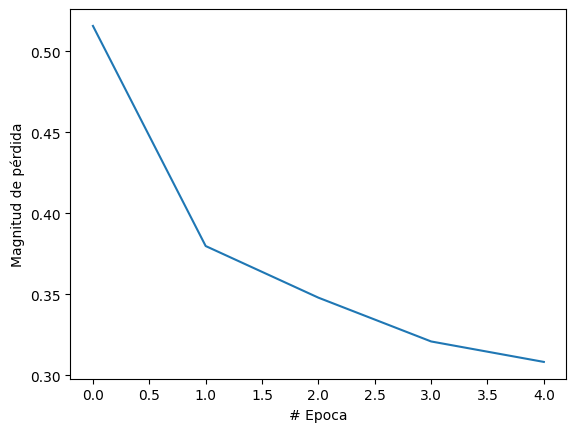

In [37]:
#Ver la función de pérdida
plt.xlabel('# Epoca')
plt.ylabel("Magnitud de pérdida")
plt.plot(historial.history["loss"])

## 13. Realizar predicciones
Imprimir 25 imágenes del set de prueba y realice la predicción de la categoría a la que pertenece cada una de esas imágenes. Identificar con una barra azul si la predicción es correcta o roja si es incorrecta

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


2026-03-09 17:56:59.334262: W tensorflow/core/kernels/data/cache_dataset_ops.cc:914] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2026-03-09 17:56:59.334360: W tensorflow/core/kernels/data/cache_dataset_ops.cc:914] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


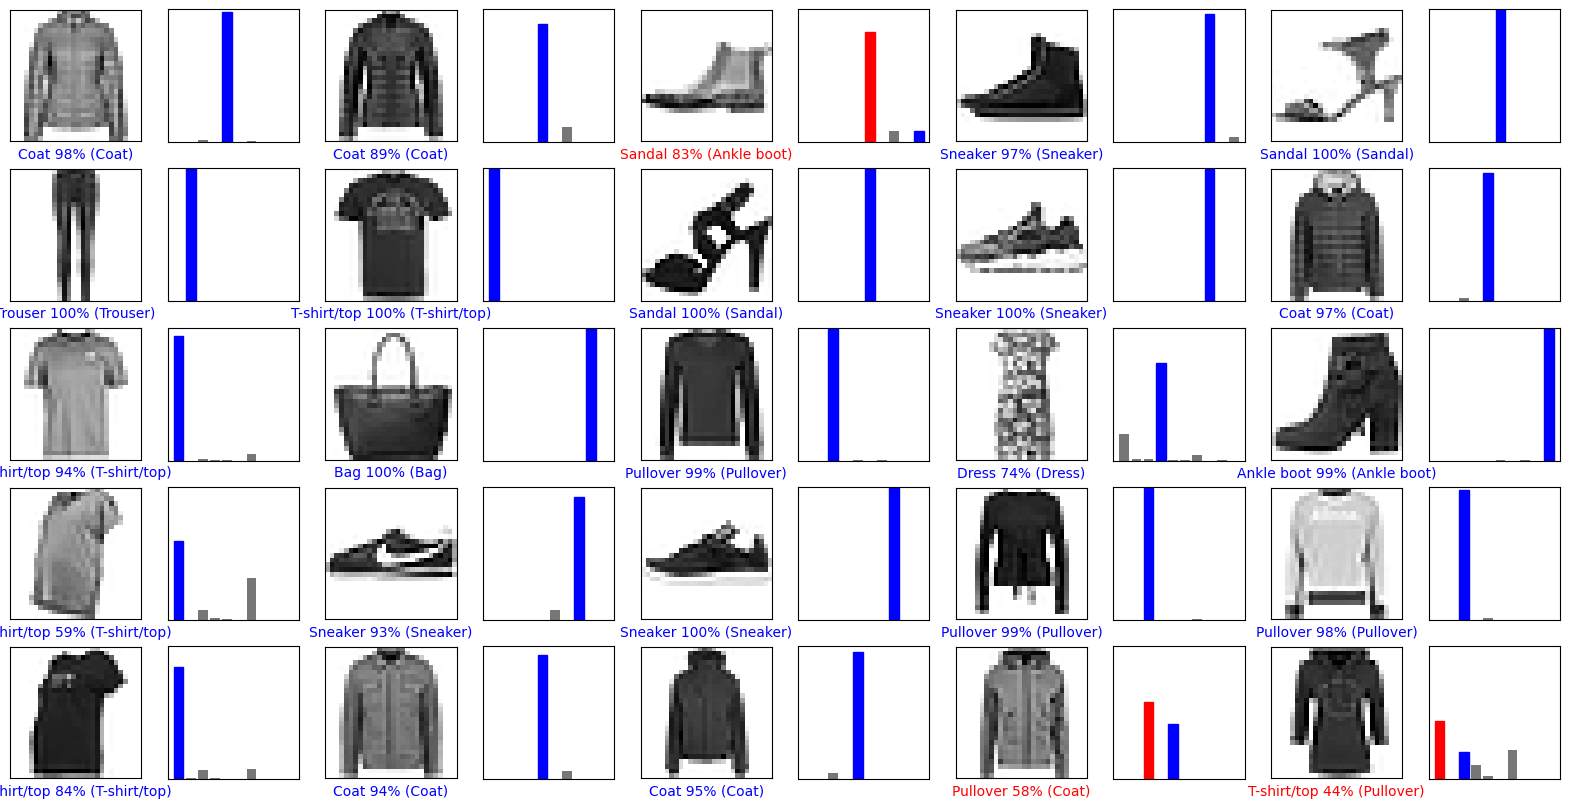

In [42]:
#Crear una cuadrícula con carias predicciones, y marcar si fue correcta (azul) o incorrecta (roja)
for imagenes_prueba, etiquetas_prueba in datos_pruebas.take(1):
    imagenes_prueba = imagenes_prueba.numpy()
    etiquetas_prueba =etiquetas_prueba.numpy()

predicciones = modelo.predict(imagenes_prueba)

def graficar_imagen(i, arr_predicciones, etiquetas_reales, imagenes):
    arr_predicciones, etiqueta_real, img = arr_predicciones[i], etiquetas_reales[i], imagenes[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img[..., 0], cmap=plt.cm.binary)

    etiqueta_prediccion = np.argmax(arr_predicciones)
    if etiqueta_prediccion == etiqueta_real:
        color = 'blue'
    else:
        color = 'red'

    plt.xlabel("{} {:.0f}% ({})".format(nombres_clases[etiqueta_prediccion],
                                100*np.max(arr_predicciones), 
                                nombres_clases[etiqueta_real]),
                                color=color)

def graficar_valor_arreglo(i, arr_predicciones, etiqueta_real):
    arr_predicciones, etiqueta_real = arr_predicciones[i], etiqueta_real[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    grafica = plt.bar(range(10), arr_predicciones, color="#777777")
    plt.ylim([0,1])
    etiqueta_prediccion = np.argmax(arr_predicciones)

    grafica[etiqueta_prediccion].set_color('red')
    grafica[etiqueta_real].set_color('blue')

filas = 5
columnas = 5
num_imagenes = filas*columnas
plt.figure(figsize=(2*2*columnas, 2*filas))
for i in range(num_imagenes):
    plt.subplot(filas, 2*columnas, 2*i+1)
    graficar_imagen(i, predicciones, etiquetas_prueba, imagenes_prueba)
    plt.subplot(filas, 2*columnas, 2*i+2)
    graficar_valor_arreglo(i, predicciones, etiquetas_prueba)


In [43]:
# Realizar la predicción de una imagen
imagen = imagenes_prueba[24]
imagen = np.array([imagen])
prediccion = modelo.predict(imagen)

print("Predicción: " + nombres_clases[np.argmax(prediccion[0])])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Predicción: T-shirt/top


## Actividades

In [48]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import io
from PIL import Image

#componente de carga de archivos
uploader = widgets.FileUpload(accept='.jpg,.png,.jpeg', multiple=False)
output = widgets.Output()

def clasificar_imagen_usuario(change):
    with output:
        clear_output() 
        
        if not uploader.value:
            return
            
        archivo = uploader.value[0] 
        contenido = archivo['content']
        
        img = Image.open(io.BytesIO(contenido)).convert('L')
        img = img.resize((28, 28)) 
        
        img_array = np.array(img)
        
        if np.mean(img_array) > 127:
            img_array = 255 - img_array
            
        img_array = img_array / 255.0
        img_array = img_array.reshape(1, 28, 28, 1) 
        
        prediccion = modelo.predict(img_array)
        clase_idx = np.argmax(prediccion[0])
        confianza = np.max(prediccion[0]) * 100
        
        plt.figure(figsize=(3,3))
        plt.imshow(img, cmap='gray')
        plt.title(f"{nombres_clases[clase_idx]} ({confianza:.1f}%)")
        plt.axis('off')
        plt.show()

uploader.observe(clasificar_imagen_usuario, names='value')

print("Sube una imagen de una prenda para clasificarla:")
display(uploader, output)

Sube una imagen de una prenda para clasificarla:


FileUpload(value=(), accept='.jpg,.png,.jpeg', description='Upload')

Output()

**¿Qué es el formato h5 y para qué sirve?**  
Es un formato jerárquico (HDF5) que guarda la arquitectura del modelo, los pesos y la configuración del optimizador en un solo archivo

In [47]:
# Exportar el modelo entrenado a formato h5
modelo.save('modelo_clasificacion_ropa.h5')
print("Modelo exportado correctamente.")

Modelo exportado correctamente.
